# Risk Predictor Training Demo
This notebook is aligned with runtime deployment: e2e sequence model, 16-frame window, 12-frame burn-in, and 4-frame prediction.
It keeps DataLoader throughput settings (`num_workers`, `prefetch_factor`, `persistent_workers`) for stable multi-epoch training.

## Step 1 - Optional Climate Model Training
Run the next cell if you want to train or resume the environment multitask model (day/night + climate).
Set `run_climate_training = False` to skip it.

In [1]:
from MIREIA.perception.climate_model_train import train_environment_model

run_climate_training = False

climate_result = None
if run_climate_training:
    climate_result = train_environment_model(
        epochs=1,
        batch_size=256,
        lr=1e-4,
        weight_decay=1e-4,
        num_workers=16,
        prefetch_factor=1,
        disable_amp=False,
        log_every=25,
        grad_accum_steps=1,
        grad_clip=None,
        image_size=512,
        dropout=0.2,
        day_loss_weight=1.0,
        weather_loss_weight=1.0,
        scenarios_root=None,
        subset_ratio=None,
        subset_seed=42,
        subset_mode="first",
        max_scenarios=None,
        frame_subset_ratio=None,
        frame_subset_seed=42,
        frame_subset_mode="random",
        checkpoint_path="",
        checkpoint_name="environment_multitask_checkpoint.pt",
        no_resume=False,
        device="",
        resize_images=False,
    )

    print("Saved:", climate_result["checkpoint_path"])
    print("Classes:", climate_result["idx_to_climate"])
    print("Final epoch:", climate_result["final_epoch"])
else:
    print("Climate training skipped (set run_climate_training=True to enable).")

Climate training skipped (set run_climate_training=True to enable).


## Step 2 - E2E Temporal Configuration
The next cell only defines sequence settings used by e2e risk training.
Check that `burn_in_frames + m_eval_frames == seq_len`.

In [1]:
import torch
torch.backends.cudnn.benchmark = True

from MIREIA.config import Config

# Runtime-aligned training setup (matches streaming inference path).
model_type = "e2e"  # use e2e sequence mode for FIFO temporal deployment
m_eval_frames = Config.INFERENCE_EVAL_FRAMES  # expected: 4
seq_len = Config.INFERENCE_SEQUENCE_LENGTH  # expected: 16
burn_in_frames = Config.INFERENCE_BURN_IN_FRAMES  # expected: 12
if burn_in_frames + m_eval_frames != seq_len:
    raise ValueError(
        f"Invalid temporal setup: burn_in({burn_in_frames}) + eval({m_eval_frames}) != seq_len({seq_len})"
    )

## Step 3 - E2E Risk Training / Resume
Run the next cell to train or resume the e2e risk model and save `e2e_result`.
`e2e_result` contains model, loaders, history, and checkpoint info used by later cells.

In [2]:
import torch
from MIREIA.config import Config
from MIREIA.perception.e2e_model_train import train_e2e_model

run_e2e_training = False

e2e_result = None
if run_e2e_training:
    e2e_result = train_e2e_model(
        resume_epochs=1,
        model_type="e2e",
        seq_len=Config.INFERENCE_SEQUENCE_LENGTH,
        burn_in_frames=Config.INFERENCE_BURN_IN_FRAMES,
        m_eval_frames=Config.INFERENCE_EVAL_FRAMES,
        batch_size=8,
        num_workers=8,
        prefetch_factor=4,
        pin_memory=True,
        persistent_workers=True,
        learning_rate=1e-4,
        use_amp=True,
        window_subset_ratio=None,
        window_subset_mode="random",
        window_subset_seed=Config.RANDOM_SEED,
        checkpoint_path="",
        checkpoint_name="e2e_risk_checkpoint.pt",
        device="cuda",
        grad_clip=None,
        grad_accum_steps=1,
    )

    # Compatibility aliases used by downstream visualization cells.
    model = e2e_result["model"]
    train_loader = e2e_result["train_loader"]
    val_loader = e2e_result["val_loader"]
    history = e2e_result["history"]
    checkpoint_path = e2e_result["checkpoint_path"]
    model_type = e2e_result.get("model_type_internal", e2e_result["model_type"])
    m_eval_frames = e2e_result["m_eval_frames"]
    seq_len = e2e_result["seq_len"]
    burn_in_frames = e2e_result["burn_in_frames"]
    target_mode = e2e_result["target_mode"]
    device = torch.device(e2e_result["device"])

    print("Saved:", e2e_result["checkpoint_path"])
    print("Final epoch:", e2e_result["final_epoch"])
else:
    print("E2E training skipped (set run_e2e_training=True to enable).")

Temporal config: seq_len=16, burn_in=12, eval=4
DataLoader workers: num_workers=8, prefetch_factor=4, persistent_workers=True
Train batches: 24199
Val batches: 4482
Batch X shape: torch.Size([8, 16, 3, 512, 512])
Batch Y shape: torch.Size([8, 16, 1])
Batch X dtype: torch.float32
Batch Y dtype: torch.float32


t:\TFG\MIREIA\perception\training_utils.py:270: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(checkpoint_path, map_location=device)


Resuming from t:\TFG\MIREIA\models\seq2seq_risk_checkpoint.pt at epoch 21


t:\TFG\MIREIA\perception\training_utils.py:104: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=amp_enabled)


Batch 1/24199 | avg loss: 0.711628 | batch shape: (8, 16, 3, 512, 512) | ETA: 168323.3s (2805.4m)
Batch 25/24199 | avg loss: 1.908450 | batch shape: (8, 16, 3, 512, 512) | ETA: 13182.6s (219.7m)
Batch 50/24199 | avg loss: 2.739639 | batch shape: (8, 16, 3, 512, 512) | ETA: 9982.3s (166.4m)
Batch 75/24199 | avg loss: 2.620765 | batch shape: (8, 16, 3, 512, 512) | ETA: 8898.5s (148.3m)
Batch 100/24199 | avg loss: 2.309668 | batch shape: (8, 16, 3, 512, 512) | ETA: 8333.6s (138.9m)
Batch 125/24199 | avg loss: 2.412186 | batch shape: (8, 16, 3, 512, 512) | ETA: 7992.8s (133.2m)
Batch 150/24199 | avg loss: 2.406135 | batch shape: (8, 16, 3, 512, 512) | ETA: 7751.0s (129.2m)
Batch 175/24199 | avg loss: 2.236798 | batch shape: (8, 16, 3, 512, 512) | ETA: 7572.5s (126.2m)
Batch 200/24199 | avg loss: 2.238849 | batch shape: (8, 16, 3, 512, 512) | ETA: 7460.9s (124.3m)
Batch 225/24199 | avg loss: 2.190781 | batch shape: (8, 16, 3, 512, 512) | ETA: 7354.4s (122.6m)
Batch 250/24199 | avg loss: 2.1

## Step 4 - Metrics Summary (Can Load History Without Training)
The next cell prints run metrics and supports checkpoint-only history loading.
If no in-memory result exists, keep `load_saved_history_only = True` to inspect saved history.

In [3]:
import os
import torch

from MIREIA.config import Config

def _default_history_checkpoint(run_name: str) -> str:
    if run_name == "climate":
        return os.path.join(Config.PATH_TO_MODELS, "environment_multitask_checkpoint.pt")
    return os.path.join(Config.PATH_TO_MODELS, "e2e_risk_checkpoint.pt")

def _load_history_only_result(run_name: str, checkpoint_path: str = "") -> dict | None:
    path = checkpoint_path or _default_history_checkpoint(run_name)
    if not os.path.isfile(path):
        print(f"Checkpoint not found: {path}")
        return None

    payload = torch.load(path, map_location="cpu")
    if not isinstance(payload, dict):
        print(f"Unsupported checkpoint payload type: {type(payload)}")
        return None

    history = payload.get("history", {})
    if not isinstance(history, dict):
        history = {}

    loaded_epoch = int(payload.get("epoch", 0))
    seq_len_loaded = int(payload.get("seq_len", Config.INFERENCE_SEQUENCE_LENGTH))
    m_eval_loaded = int(payload.get("m_eval_frames", Config.INFERENCE_EVAL_FRAMES))
    raw_type = str(payload.get("model_type_internal", payload.get("model_type", "e2e"))).lower()
    model_type_internal = "single" if raw_type == "single" else "e2e"

    return {
        "history": history,
        "checkpoint_path": path,
        "model_type": "environment_multitask" if run_name == "climate" else "e2e",
        "model_type_internal": "environment_multitask" if run_name == "climate" else model_type_internal,
        "m_eval_frames": m_eval_loaded,
        "seq_len": seq_len_loaded,
        "burn_in_frames": max(0, seq_len_loaded - m_eval_loaded),
        "target_mode": payload.get("target_mode", "sequence"),
        "idx_to_climate": payload.get("idx_to_climate", []),
        "climate_to_idx": payload.get("climate_to_idx", {}),
        "device": "cpu",
        "start_epoch": loaded_epoch + 1,
        "final_epoch": loaded_epoch,
    }

# Summary metrics (supports both e2e and climate runs)
visualize_run = "e2e"  # "e2e" or "climate"
load_saved_history_only = True  # True lets you inspect metrics without training now
history_checkpoint_path = ""  # Optional explicit checkpoint path

if visualize_run == "climate":
    active_result = climate_result if "climate_result" in globals() else None
elif visualize_run == "e2e":
    active_result = e2e_result if "e2e_result" in globals() else None
else:
    raise ValueError("visualize_run must be 'e2e' or 'climate'")

if active_result is None and load_saved_history_only:
    active_result = _load_history_only_result(visualize_run, history_checkpoint_path)
    if active_result is not None:
        print(f"Loaded history-only result from: {active_result['checkpoint_path']}")

if active_result is None:
    print(f"No result found for {visualize_run}. Run training or enable history loading.")
else:
    active_train_loader = active_result.get("train_loader")
    active_val_loader = active_result.get("val_loader")
    active_history = active_result.get("history", {})

    train_samples = len(active_train_loader.dataset) if active_train_loader is not None else 0
    val_samples = len(active_val_loader.dataset) if active_val_loader is not None else 0
    train_batches = len(active_train_loader) if active_train_loader is not None else 0
    val_batches = len(active_val_loader) if active_val_loader is not None else 0

    print(f"Run: {visualize_run}")
    print(f"Checkpoint: {active_result.get('checkpoint_path', '(in-memory only)')}")
    print(f"Train samples: {train_samples}")
    print(f"Val samples:   {val_samples}")
    print(f"Train batches: {train_batches}")
    print(f"Val batches:   {val_batches}")

    if active_history.get("train_loss"):
        print(f"Best train loss: {min(active_history['train_loss']):.6f}")
    if active_history.get("val_loss"):
        print(f"Best val loss:   {min(active_history['val_loss']):.6f}")
    if active_history.get("train_day_acc"):
        print(f"Best train day acc:     {max(active_history['train_day_acc']):.4f}")
    if active_history.get("train_weather_acc"):
        print(f"Best train climate acc: {max(active_history['train_weather_acc']):.4f}")
    if active_history.get("val_day_acc"):
        print(f"Best val day acc:       {max(active_history['val_day_acc']):.4f}")
    if active_history.get("val_weather_acc"):
        print(f"Best val climate acc:   {max(active_history['val_weather_acc']):.4f}")

if torch.cuda.is_available():
    mem_alloc = torch.cuda.max_memory_allocated() / (1024 ** 3)
    mem_reserved = torch.cuda.max_memory_reserved() / (1024 ** 3)
    print(f"Peak CUDA allocated: {mem_alloc:.2f} GB")
    print(f"Peak CUDA reserved:  {mem_reserved:.2f} GB")

Train samples: 193590
Val samples:   35850
Train batches: 24199
Val batches:   4482
Best train loss: 0.569618
Best val loss:   5.736896
Peak CUDA allocated: 9.68 GB
Peak CUDA reserved:  10.94 GB


## Step 5 - Training Curves
The next cell plots losses (and climate accuracies when applicable).
It can also run from checkpoint history if `load_saved_history_only = True`.

C:\Users\mique\AppData\Local\Temp\ipykernel_33496\1184789634.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  payload = torch.load(path, map_location="cpu")


Loaded history-only result from: t:\TFG\MIREIA\models\e2e_risk_checkpoint.pt


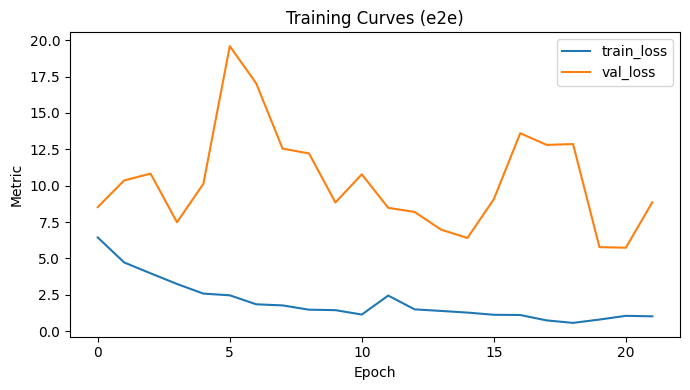

In [4]:
import os
import matplotlib.pyplot as plt
import torch

from MIREIA.config import Config

if "_load_history_only_result" not in globals():
    def _default_history_checkpoint(run_name: str) -> str:
        if run_name == "climate":
            return os.path.join(Config.PATH_TO_MODELS, "environment_multitask_checkpoint.pt")
        return os.path.join(Config.PATH_TO_MODELS, "e2e_risk_checkpoint.pt")

    def _load_history_only_result(run_name: str, checkpoint_path: str = "") -> dict | None:
        path = checkpoint_path or _default_history_checkpoint(run_name)
        if not os.path.isfile(path):
            print(f"Checkpoint not found: {path}")
            return None
        payload = torch.load(path, map_location="cpu")
        if not isinstance(payload, dict):
            print(f"Unsupported checkpoint payload type: {type(payload)}")
            return None
        history = payload.get("history", {})
        if not isinstance(history, dict):
            history = {}
        raw_type = str(payload.get("model_type_internal", payload.get("model_type", "e2e"))).lower()
        model_type_internal = "single" if raw_type == "single" else "e2e"
        return {
            "history": history,
            "checkpoint_path": path,
            "model_type": "environment_multitask" if run_name == "climate" else "e2e",
            "model_type_internal": "environment_multitask" if run_name == "climate" else model_type_internal,
        }

# Loss plot for either e2e or climate run
visualize_run = "e2e"  # "e2e" or "climate"
load_saved_history_only = True
history_checkpoint_path = ""

if visualize_run == "climate":
    active_result = climate_result if "climate_result" in globals() else None
elif visualize_run == "e2e":
    active_result = e2e_result if "e2e_result" in globals() else None
else:
    raise ValueError("visualize_run must be 'e2e' or 'climate'")

if active_result is None and load_saved_history_only:
    active_result = _load_history_only_result(visualize_run, history_checkpoint_path)
    if active_result is not None:
        print(f"Loaded history-only result from: {active_result['checkpoint_path']}")

if active_result is None:
    print(f"No result found for {visualize_run}. Run training or enable history loading.")
else:
    active_history = active_result.get("history", {})

    if active_history.get("train_loss"):
        plt.figure(figsize=(7, 4))
        plt.plot(active_history["train_loss"], label="train_loss")
        if active_history.get("val_loss"):
            plt.plot(active_history["val_loss"], label="val_loss")

        if visualize_run == "climate":
            if active_history.get("train_day_acc"):
                plt.plot(active_history["train_day_acc"], label="train_day_acc")
            if active_history.get("val_day_acc"):
                plt.plot(active_history["val_day_acc"], label="val_day_acc")
            if active_history.get("train_weather_acc"):
                plt.plot(active_history["train_weather_acc"], label="train_climate_acc")
            if active_history.get("val_weather_acc"):
                plt.plot(active_history["val_weather_acc"], label="val_climate_acc")

        plt.xlabel("Epoch")
        plt.ylabel("Metric")
        plt.title(f"Training Curves ({visualize_run})")
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print("No training history found in the selected run/checkpoint.")

## Step 6 - Optional Road Segmentation Training (Dual-Head Multitask)
Run the next cell to train one compact model that predicts both lane lines and drivable road masks.
Set `run_road_seg_training = False` to skip training and use checkpoint loading in later cells.

In [15]:
import importlib
import torch

from MIREIA.config import Config
import MIREIA.perception.road_segmentation as road_seg_model_module
import MIREIA.perception.road_segmentation_train as road_seg_train_module

# Reload model first, then trainer, so trainer binds the latest model class.
road_seg_model_module = importlib.reload(road_seg_model_module)
road_seg_train_module = importlib.reload(road_seg_train_module)
train_road_segmentation_model = road_seg_train_module.train_road_segmentation_model

run_road_seg_training = True

road_seg_result = None
if run_road_seg_training:
    road_seg_result = train_road_segmentation_model(
        dataset_name="bnsapa/road-detection",
        epochs=50,
        batch_size=1,
        lr=1e-4,
        weight_decay=1e-4,
        image_size=256,
        dropout=0.1,
        backbone_pretrained=True,
        num_workers=8,  # safer default on Windows shared-memory limits
        pin_memory=torch.cuda.is_available(),
        prefetch_factor=4,
        persistent_workers=False,
        subset_ratio=None,
        val_subset_ratio=None,
        subset_seed=Config.RANDOM_SEED,
        subset_mode="random",
        disable_amp=False,
        pred_threshold=0.5,
        lane_loss_weight=1.0,
        road_loss_weight=1.0,
        grad_accum_steps=1,
        grad_clip=None,
        checkpoint_path="",
        checkpoint_name="road_segmentation_multitask_checkpoint.pt",
        best_checkpoint_path="",
        best_checkpoint_name="road_segmentation_multitask_best.pt",
        no_resume=False,
        device="",
        log_every=25,
    )

    print("Road segmentation checkpoint:", road_seg_result["checkpoint_path"])
    print("Best checkpoint:", road_seg_result["best_checkpoint_path"])
    print("Best mean IoU:", f"{road_seg_result['best_mean_iou']:.4f}")
    print("Final epoch:", road_seg_result["final_epoch"])
else:
    print("Road segmentation training skipped (set run_road_seg_training=True to enable).")

No checkpoint resume. Starting fresh at t:\TFG\MIREIA\models\road_segmentation_multitask_checkpoint.pt
Epoch 1/50 | batch 1/160 | loss=1.376011 | lane_iou=0.0044 | road_iou=0.1116 | mean_iou=0.0580
Epoch 1/50 | batch 25/160 | loss=1.279626 | lane_iou=0.0315 | road_iou=0.3837 | mean_iou=0.2076
Epoch 1/50 | batch 50/160 | loss=1.227093 | lane_iou=0.0398 | road_iou=0.4586 | mean_iou=0.2492
Epoch 1/50 | batch 75/160 | loss=1.207885 | lane_iou=0.0406 | road_iou=0.4753 | mean_iou=0.2580
Epoch 1/50 | batch 100/160 | loss=1.170386 | lane_iou=0.0445 | road_iou=0.5189 | mean_iou=0.2817
Epoch 1/50 | batch 125/160 | loss=1.156368 | lane_iou=0.0466 | road_iou=0.5295 | mean_iou=0.2880
Epoch 1/50 | batch 150/160 | loss=1.135611 | lane_iou=0.0531 | road_iou=0.5462 | mean_iou=0.2997
Epoch 1/50 summary | train_loss=1.125777, val_loss=1.036715 | train_mean_iou=0.3058, val_mean_iou=0.3691 | train_lane_iou=0.0550, val_lane_iou=0.0640 | train_road_iou=0.5566, val_road_iou=0.6741
Saved new best checkpoint (m

## Step 7 - Segmentation Metrics Summary (Lane + Road)
The next cell reports multitask training and validation metrics for both heads.
If no in-memory result exists, it can load metadata and history from a saved checkpoint.

In [16]:
import importlib
import os

from MIREIA.config import Config
import MIREIA.perception.road_segmentation as road_seg_model_module
import MIREIA.perception.road_segmentation_train as road_seg_train_module

# Reload model first, then trainer, so loader paths bind the latest model class.
road_seg_model_module = importlib.reload(road_seg_model_module)
road_seg_train_module = importlib.reload(road_seg_train_module)
load_road_segmentation_model = road_seg_train_module.load_road_segmentation_model

seg_checkpoint_name = "road_segmentation_multitask_checkpoint.pt"
seg_checkpoint_path = os.path.join(Config.PATH_TO_MODELS, seg_checkpoint_name)
load_saved_seg_result = True

active_seg_result = road_seg_result if "road_seg_result" in globals() else None
if active_seg_result is None and load_saved_seg_result:
    if os.path.isfile(seg_checkpoint_path):
        active_seg_result = load_road_segmentation_model(checkpoint_path=seg_checkpoint_path)
        print(f"Loaded segmentation result from: {active_seg_result['checkpoint_path']}")
    else:
        print(f"Checkpoint not found: {seg_checkpoint_path}")

if active_seg_result is None:
    print("No road segmentation result found. Run training or provide a valid checkpoint.")
else:
    seg_history = active_seg_result.get("history", {})
    print("Run: road_segmentation_multitask")
    print("Tasks:", active_seg_result.get("tasks", ["lane", "road"]))
    print("Dataset:", active_seg_result.get("dataset_name", "bnsapa/road-detection"))
    print("Checkpoint:", active_seg_result.get("checkpoint_path", "(in-memory only)"))
    print("Image size:", active_seg_result.get("image_size", (256, 256)))
    print("Threshold:", active_seg_result.get("pred_threshold", 0.5))
    print("Best mean IoU:", f"{float(active_seg_result.get('best_mean_iou', 0.0)):.4f}")
    print("Final epoch:", int(active_seg_result.get("final_epoch", 0)))

    if seg_history.get("train_loss"):
        print("Best train loss:", f"{min(seg_history['train_loss']):.6f}")
    if seg_history.get("val_loss"):
        print("Best val loss:", f"{min(seg_history['val_loss']):.6f}")

    if seg_history.get("train_lane_iou"):
        print("Best train lane IoU:", f"{max(seg_history['train_lane_iou']):.4f}")
    if seg_history.get("val_lane_iou"):
        print("Best val lane IoU:", f"{max(seg_history['val_lane_iou']):.4f}")
    if seg_history.get("train_road_iou"):
        print("Best train road IoU:", f"{max(seg_history['train_road_iou']):.4f}")
    if seg_history.get("val_road_iou"):
        print("Best val road IoU:", f"{max(seg_history['val_road_iou']):.4f}")
    if seg_history.get("train_mean_iou"):
        print("Best train mean IoU:", f"{max(seg_history['train_mean_iou']):.4f}")
    if seg_history.get("val_mean_iou"):
        print("Best val mean IoU:", f"{max(seg_history['val_mean_iou']):.4f}")

    if seg_history.get("train_lane_dice"):
        print("Best train lane Dice:", f"{max(seg_history['train_lane_dice']):.4f}")
    if seg_history.get("val_lane_dice"):
        print("Best val lane Dice:", f"{max(seg_history['val_lane_dice']):.4f}")
    if seg_history.get("train_road_dice"):
        print("Best train road Dice:", f"{max(seg_history['train_road_dice']):.4f}")
    if seg_history.get("val_road_dice"):
        print("Best val road Dice:", f"{max(seg_history['val_road_dice']):.4f}")
    if seg_history.get("train_mean_dice"):
        print("Best train mean Dice:", f"{max(seg_history['train_mean_dice']):.4f}")
    if seg_history.get("val_mean_dice"):
        print("Best val mean Dice:", f"{max(seg_history['val_mean_dice']):.4f}")

Run: road_segmentation_multitask
Tasks: ['lane', 'road']
Dataset: bnsapa/road-detection
Checkpoint: t:\TFG\MIREIA\models\road_segmentation_multitask_checkpoint.pt
Image size: (256, 256)
Threshold: 0.5
Best mean IoU: 0.5791
Final epoch: 50
Best train loss: 0.134957
Best val loss: 0.216299
Best train lane IoU: 0.5866
Best val lane IoU: 0.4050
Best train road IoU: 0.9186
Best val road IoU: 0.7790
Best train mean IoU: 0.7510
Best val mean IoU: 0.5791
Best train lane Dice: 0.7038
Best val lane Dice: 0.5376
Best train road Dice: 0.9549
Best val road Dice: 0.8704
Best train mean Dice: 0.8275
Best val mean Dice: 0.6836


## Step 8 - Optional Speed Fusion Training (YOLO + RAFT + Depth)
Trains the fused two-frame speed regressor using scenario JSONL labels (`true_ego_speed` by default).
Set `run_speed_fusion_training = True` to launch training/resume and save `speed_fusion_result`.

No checkpoint found for speed fusion model. Starting fresh.
Train batches: 900
Val batches: 900
Model device: cuda
Feature device: cuda
Epoch 1 | Batch 1/900 | loss=39.663223 | rmse=6.297875
Epoch 1 | Batch 10/900 | loss=23.993338 | rmse=4.898299
Epoch 1 | Batch 20/900 | loss=24.653135 | rmse=4.965192
Epoch 1 | Batch 30/900 | loss=19.725951 | rmse=4.441391
Epoch 1 | Batch 40/900 | loss=17.214964 | rmse=4.149092
Epoch 1 | Batch 50/900 | loss=15.763767 | rmse=3.970361
Epoch 1 | Batch 60/900 | loss=14.288194 | rmse=3.779973
Epoch 1 | Batch 70/900 | loss=13.956948 | rmse=3.735900
Epoch 1 | Batch 80/900 | loss=13.372452 | rmse=3.656836
Epoch 1 | Batch 90/900 | loss=13.135555 | rmse=3.624301
Epoch 1 | Batch 100/900 | loss=12.778039 | rmse=3.574638
Epoch 1 | Batch 110/900 | loss=12.557722 | rmse=3.543688
Epoch 1 | Batch 120/900 | loss=12.273957 | rmse=3.503421
Epoch 1 | Batch 130/900 | loss=12.072571 | rmse=3.474560
Epoch 1 | Batch 140/900 | loss=11.828024 | rmse=3.439189
Epoch 1 | Batch 150/

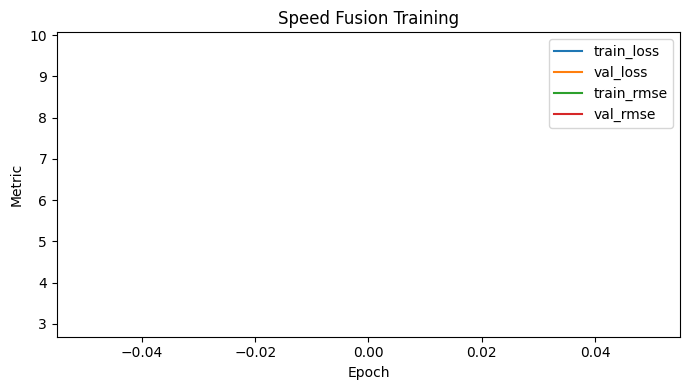

: 

In [ ]:
import os

import matplotlib.pyplot as plt
import torch

from MIREIA.config import Config
from MIREIA.perception import train_speed_fusion_model

run_speed_fusion_training = True
device_name = "cuda" if torch.cuda.is_available() else "cpu"

speed_fusion_result = None
if run_speed_fusion_training:
    speed_fusion_result = train_speed_fusion_model(
        resume_epochs=1,
        batch_size=4,
        learning_rate=3e-4,
        scenarios_root=Config.PATH_TO_SCENARIOS,
        speed_key="true_ego_speed",
        checkpoint_name="speed_fusion_checkpoint.pt",
        checkpoint_path="",
        model_device=device_name,
        feature_device=device_name,
        cache_dir=os.path.join(Config.PATH_TO_MODELS, "speed_fusion_cache"),
        max_ram_cache_entries=256,
        num_workers=0,
        pin_memory=False,
        max_scenarios=None,
        subset_ratio=0.005,
        pair_stride=1,
        pair_subset_ratio=None,
        log_every=10,
        grad_clip=None,
        use_cache=True,
    )

    print("Saved:", speed_fusion_result["checkpoint_path"])

    history = speed_fusion_result.get("history", {})
    if history.get("train_loss"):
        plt.figure(figsize=(7, 4))
        plt.plot(history["train_loss"], label="train_loss")
        if history.get("val_loss"):
            plt.plot(history["val_loss"], label="val_loss")
        if history.get("train_rmse"):
            plt.plot(history["train_rmse"], label="train_rmse")
        if history.get("val_rmse"):
            plt.plot(history["val_rmse"], label="val_rmse")
        plt.xlabel("Epoch")
        plt.ylabel("Metric")
        plt.title("Speed Fusion Training")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("Speed fusion training skipped (set run_speed_fusion_training=True to enable).")